In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset=pd.read_csv("Country.csv")

In [ ]:
dataset

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
dataset.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [ ]:
x=dataset.drop("country",axis=1)

In [ ]:
y=dataset["country"]

In [ ]:
dataset["country"].value_counts()

,count
country,
Afghanistan,1
Albania,1
Algeria,1
Angola,1
Antigua and Barbuda,1
...,...
Vanuatu,1
Venezuela,1
Vietnam,1


In [ ]:
x.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  model=KMeans(n_clusters=i,random_state=0)
  model.fit(x)
  wcss.append(model.inertia_)


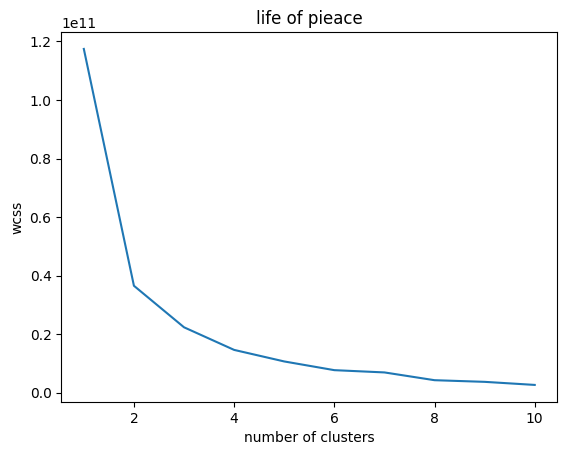

In [ ]:
plt.plot(range(1,11),wcss)
plt.title("life of pieace")
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [ ]:
model=KMeans(n_clusters=3,random_state=0)
y_means=model.fit_predict(x)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca= pca.fit_transform(x)

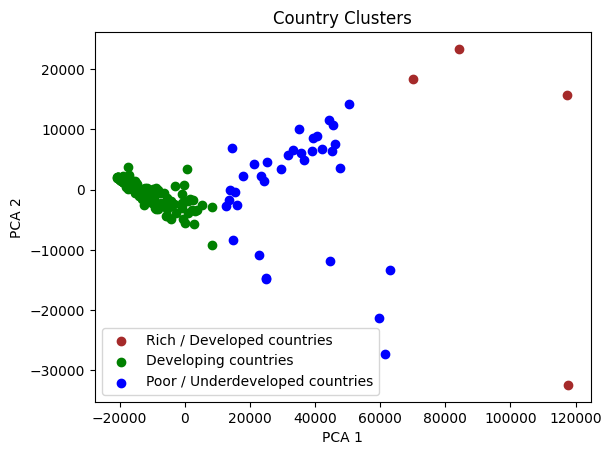

In [ ]:


plt.scatter(X_pca[y_means==0, 0], X_pca[y_means==0, 1], c="brown", label="Rich / Developed countries")
plt.scatter(X_pca[y_means==1, 0], X_pca[y_means==1, 1], c="green", label="Developing countries")
plt.scatter(X_pca[y_means==2, 0], X_pca[y_means==2, 1], c="blue", label="Poor / Underdeveloped countries")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Country Clusters")
plt.legend()
plt.show()

In [ ]:
developed_countries = y[y_means == 0]
display(developed_countries)

,country
91,Luxembourg
114,Norway
123,Qatar
145,Switzerland


In [ ]:
developing_countries=y[y_means==1]
display(developing_countries)

,country
0,Afghanistan
1,Albania
2,Algeria
3,Angola
4,Antigua and Barbuda
...,...
162,Vanuatu
163,Venezuela
164,Vietnam
165,Yemen


In [ ]:
developing_countries.size

128

In [ ]:
developing_countries.head(50)

,country
0,Afghanistan
1,Albania
2,Algeria
3,Angola
4,Antigua and Barbuda
5,Argentina
6,Armenia
9,Azerbaijan
12,Bangladesh
13,Barbados


In [ ]:
developing_countries.tail(30)

,country
127,Samoa
129,Senegal
130,Serbia
131,Seychelles
132,Sierra Leone
134,Slovak Republic
136,Solomon Islands
137,South Africa
140,Sri Lanka
141,St. Vincent and the Grenadines


In [ ]:
Undeveloped_countries = y[y_means == 2]
display(Undeveloped_countries)

,country
7,Australia
8,Austria
10,Bahamas
11,Bahrain
15,Belgium
23,Brunei
29,Canada
42,Cyprus
43,Czech Republic
44,Denmark


In [ ]:
developed_countries_gdp = dataset[dataset['country'].isin(developed_countries)]
display(developed_countries_gdp[['country', 'gdpp']])

,country,gdpp
91,Luxembourg,105000
114,Norway,87800
123,Qatar,70300
145,Switzerland,74600


In [ ]:


developing_countries_gdp = dataset[dataset['country'].isin(developing_countries)]
display(developing_countries_gdp[['country', 'gdpp']])
developing_countries_gdp.head(10)

,country,gdpp
0,Afghanistan,553
1,Albania,4090
2,Algeria,4460
3,Angola,3530
4,Antigua and Barbuda,12200
...,...,...
162,Vanuatu,2970
163,Venezuela,13500
164,Vietnam,1310
165,Yemen,1310


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840
12,Bangladesh,49.4,16.0,3.52,21.8,2440,7.140,70.4,2.33,758
13,Barbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000
